# 03 — Training: EfficientNetB3 Transfer Learning
WBC Classification · 9 classes · 300×300 input

**Two-phase strategy:**
- **Phase 1** — Frozen EfficientNetB3 base, train classification head only (10–15 epochs)
- **Phase 2** — Unfreeze top ~85 layers, fine-tune with very low LR (15–20 epochs)

Start with Phase 1 to stabilise the head weights before unfreezing.
This prevents early fine-tuning from destroying ImageNet features.

In [1]:
import sys
sys.path.append('../src')

import os
import numpy as np
import tensorflow as tf
from pathlib import Path
from datetime import datetime

from dataset import build_dataset, get_class_weights, CLASSES, NUM_CLASSES
from model   import build_model, compile_phase1, compile_phase2, unfreeze_top_layers
from utils   import plot_training_history

print('TensorFlow version:', tf.__version__)
print('GPUs available    :', tf.config.list_physical_devices('GPU'))

# ── Paths ──────────────────────────────────────────────────────────────────
DATA_DIR     = Path('../data/processed')
MODELS_DIR   = Path('../models')
RESULTS_DIR  = Path('../results')
CKPT_DIR     = MODELS_DIR / 'checkpoints'
FINAL_DIR    = MODELS_DIR / 'final'

for d in [CKPT_DIR, FINAL_DIR, RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

TensorFlow version: 2.10.0
GPUs available    : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Hyperparameters
Tune these first if results are poor — batch size and learning rate are the most impactful.

In [2]:
# ── Hyperparameters ────────────────────────────────────────────────────────
BATCH_SIZE     = 32      # Reduce to 16 if OOM; increase to 64 on high-VRAM GPU
PHASE1_EPOCHS  = 15      # Head-only warmup
PHASE2_EPOCHS  = 20      # Fine-tuning unfrozen top layers
PHASE1_LR      = 1e-3
PHASE2_LR      = 1e-5    # Must be much lower to avoid destroying ImageNet weights
USE_CLASS_WEIGHTS = False#True # Recommended if imbalance ratio > 3× (check EDA notebook)

## Data Pipelines

In [3]:
train_ds = build_dataset(DATA_DIR / 'train', batch_size=BATCH_SIZE, augment=True,  shuffle=True)
val_ds   = build_dataset(DATA_DIR / 'val',   batch_size=BATCH_SIZE, augment=False, shuffle=False)

# Class weights for imbalanced dataset
class_weights = get_class_weights(DATA_DIR / 'train') if USE_CLASS_WEIGHTS else None
if class_weights:
    print('\nClass weights:')
    for i, cls in enumerate(CLASSES):
        print(f'  [{i}] {cls:<25s}: {class_weights[i]:.3f}')

[dataset] train: 9613 images across 9 classes
[dataset] val: 3202 images across 9 classes


## Build Model

In [4]:
model = build_model(num_classes=NUM_CLASSES)
model.summary(line_length=90, expand_nested=False)

Model: "EfficientNetB3_WBC"
__________________________________________________________________________________________
 Layer (type)                           Output Shape                        Param #       
 input_image (InputLayer)               [(None, 300, 300, 3)]               0             
                                                                                          
 efficientnetb3 (Functional)            (None, 10, 10, 1536)                10783535      
                                                                                          
 gap (GlobalAveragePooling2D)           (None, 1536)                        0             
                                                                                          
 bn_head (BatchNormalization)           (None, 1536)                        6144          
                                                                                          
 dropout_1 (Dropout)                    (None, 1536)          

## Phase 1 — Train Classification Head (base frozen)

In [17]:
model = compile_phase1(model, learning_rate=PHASE1_LR)

callbacks_p1 = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(CKPT_DIR / 'phase1_best.keras'),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1,
        save_weights_only=True,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1,
    ),
    tf.keras.callbacks.TensorBoard(
        log_dir=str(RESULTS_DIR / 'logs' / 'phase1'),
        histogram_freq=1,
    ),
]

history_p1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=PHASE1_EPOCHS,
    callbacks=callbacks_p1,
    #class_weight=class_weights,
)

print('\nPhase 1 complete.')
print(f'Best val accuracy: {max(history_p1.history["val_accuracy"]):.4f}')

  Total params     : 11,185,464
  Trainable params : 7,273,275  (65.0%)
  Frozen params    : 3,912,189
Epoch 1/15
301/301 [==============================] - ETA: 0s - loss: 0.4615 - accuracy: 0.8948
Epoch 1: val_accuracy improved from -inf to 0.85978, saving model to ..\models\checkpoints\phase1_best.keras
301/301 [==============================] - 75s 233ms/step - loss: 0.4615 - accuracy: 0.8948 - val_loss: 0.5012 - val_accuracy: 0.8598 - lr: 0.0010
Epoch 2/15
301/301 [==============================] - ETA: 0s - loss: 0.3045 - accuracy: 0.9406
Epoch 2: val_accuracy improved from 0.85978 to 0.91974, saving model to ..\models\checkpoints\phase1_best.keras
301/301 [==============================] - 69s 229ms/step - loss: 0.3045 - accuracy: 0.9406 - val_loss: 0.3920 - val_accuracy: 0.9197 - lr: 0.0010
Epoch 3/15
301/301 [==============================] - ETA: 0s - loss: 0.2721 - accuracy: 0.9534
Epoch 3: val_accuracy did not improve from 0.91974
301/301 [==============================] - 

[utils] Training curves saved → ..\results\phase1_training_curves.png


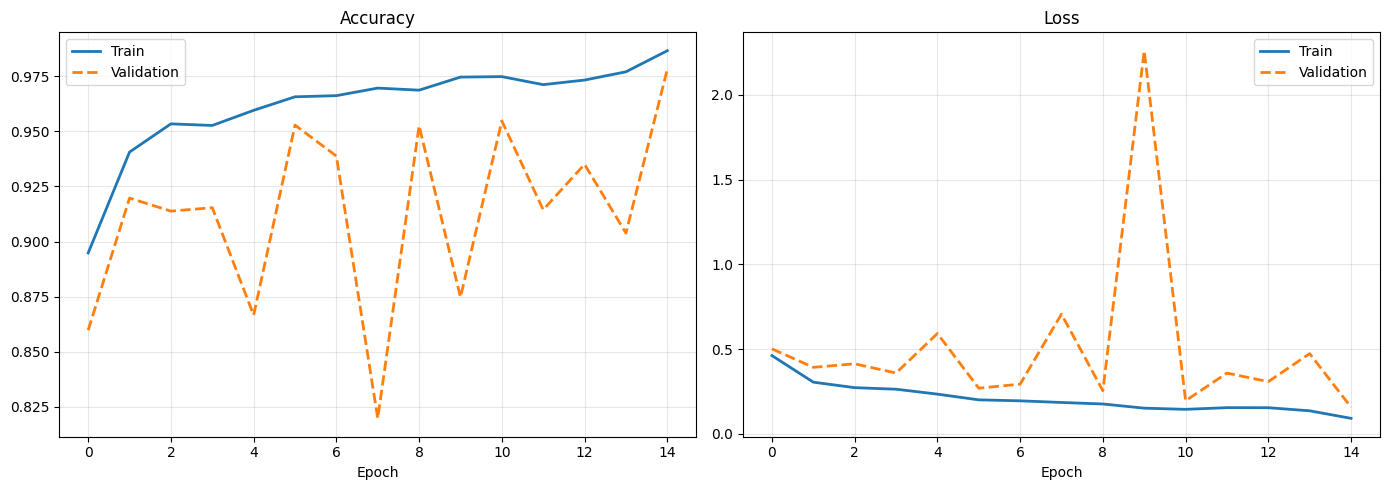

In [18]:
plot_training_history(
    history_p1.history,
    save_path=RESULTS_DIR / 'phase1_training_curves.png'
)

## Phase 2 — Fine-tune Top Layers (partial unfreeze)

We unfreeze layers from `UNFREEZE_FROM_LAYER` onwards in EfficientNetB3.
All BatchNormalization layers stay frozen — this is critical for stability.

Using SGD + Nesterov momentum at LR=1e-5 (much safer than Adam for fine-tuning).

In [19]:
# Load best Phase 1 weights before unfreezing
model.load_weights(str(CKPT_DIR / 'phase1_best.keras'))

model = unfreeze_top_layers(model)
model = compile_phase2(model, learning_rate=PHASE2_LR)

callbacks_p2 = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(CKPT_DIR / 'phase2_best.keras'),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1,
        save_weights_only=True,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=7,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1,
    ),
    tf.keras.callbacks.TensorBoard(
        log_dir=str(RESULTS_DIR / 'logs' / 'phase2'),
        histogram_freq=1,
    ),
]

history_p2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=PHASE2_EPOCHS,
    callbacks=callbacks_p2,
    class_weight=class_weights,
)

print('\nPhase 2 complete.')
print(f'Best val accuracy: {max(history_p2.history["val_accuracy"]):.4f}')

  Total params     : 11,185,464
  Trainable params : 7,273,275  (65.0%)
  Frozen params    : 3,912,189
Epoch 1/20
301/301 [==============================] - ETA: 0s - loss: 0.0747 - accuracy: 0.9926
Epoch 1: val_accuracy improved from -inf to 0.97252, saving model to ..\models\checkpoints\phase2_best.keras
301/301 [==============================] - 75s 234ms/step - loss: 0.0747 - accuracy: 0.9926 - val_loss: 0.1696 - val_accuracy: 0.9725 - lr: 1.0000e-05
Epoch 2/20
301/301 [==============================] - ETA: 0s - loss: 0.0758 - accuracy: 0.9919
Epoch 2: val_accuracy did not improve from 0.97252
301/301 [==============================] - 69s 227ms/step - loss: 0.0758 - accuracy: 0.9919 - val_loss: 0.1703 - val_accuracy: 0.9722 - lr: 1.0000e-05
Epoch 3/20
301/301 [==============================] - ETA: 0s - loss: 0.0730 - accuracy: 0.9915
Epoch 3: val_accuracy did not improve from 0.97252
301/301 [==============================] - 69s 228ms/step - loss: 0.0730 - accuracy: 0.9915 - va

[utils] Training curves saved → ..\results\phase2_training_curves.png


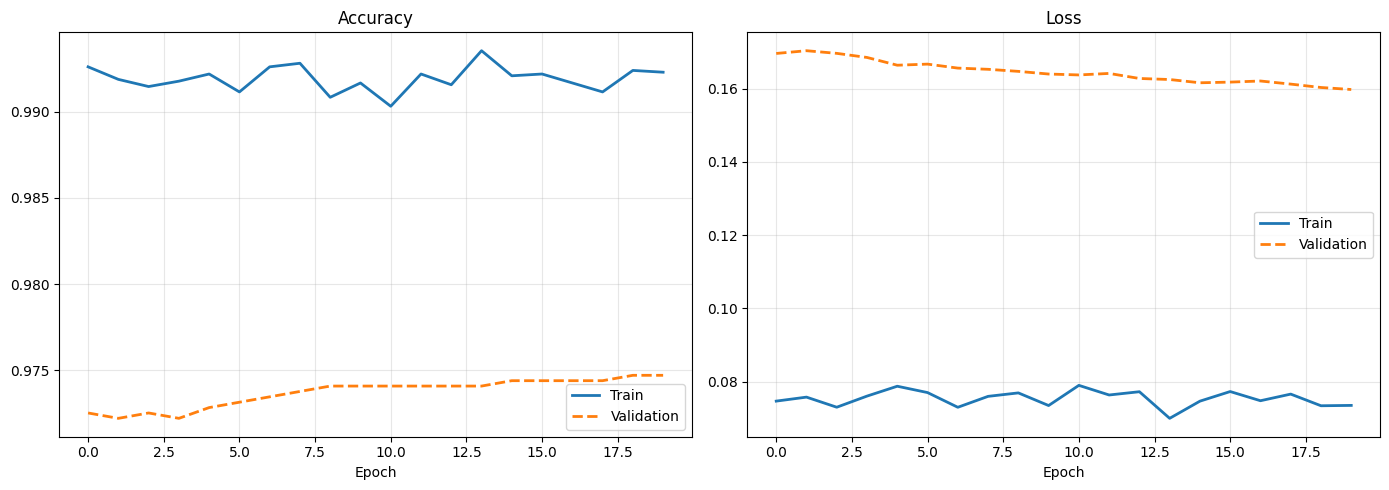

In [20]:
plot_training_history(
    history_p2.history,
    save_path=RESULTS_DIR / 'phase2_training_curves.png'
)

## Save Final Model

In [25]:
# Load best Phase 2 weights
model.load_weights(str(CKPT_DIR / 'phase2_best.keras'))

In [28]:

# Save in native Keras format
final_path = FINAL_DIR / 'efficientnetb3_wbc_final.keras'
model.save(final_path)
print(f'Final model saved → {final_path}')


TypeError: Unable to serialize [2.0896919 2.1128857 2.1081853] to JSON. Unrecognized type <class 'tensorflow.python.framework.ops.EagerTensor'>.

In [27]:
# Quick sanity check on validation set
val_loss, val_acc = model.evaluate(val_ds, verbose=1)
print(f'\nValidation  accuracy: {val_acc:.4f}')
#print(f'Validation  AUC     : {val_auc:.4f}')
print(f'Validation  loss    : {val_loss:.4f}')

101/101 [==============================] - 15s 150ms/step - loss: 0.1603 - accuracy: 0.9747

Validation  accuracy: 0.9747
Validation  loss    : 0.1603
